# Project 4 Risk Analysis (Cleaned Version)
Refactored for readability and presentation.

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
# Load source datasets and shapefile layers
fl_nri = pd.read_csv("NRI_Table_CensusTracts_Florida.csv")
fl_svi = pd.read_csv("Florida.csv")

la_nri = pd.read_csv("NRI_Table_CensusTracts_Louisiana.csv")
la_svi = pd.read_csv("Louisiana.csv")

tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")
tracts = tracts.replace(-9999, np.nan)

# Load data dictionary for field descriptions
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

# Create common merge key for county-level joins
fl_nri["STCNTY"] = fl_nri["STCOFIPS"]
la_nri["STCNTY"] = la_nri["STCOFIPS"]

# Merge NRI and SVI data for each state
fl_complete_data = pd.merge(
    fl_nri, fl_svi,
    on="STCNTY",
    suffixes=("", "_right"))

la_complete_data = pd.merge(
    la_nri, la_svi,
    on="STCNTY",
    suffixes=("", "_right"))

# Identify numeric columns for missing-value treatment
num_cols = fl_complete_data.select_dtypes(
    include=["int64", "float64"]).columns

# Replace missing numeric values with column medians
fl_complete_data[num_cols] = fl_complete_data[num_cols].fillna(
    fl_complete_data[num_cols].median())

la_complete_data[num_cols] = la_complete_data[num_cols].fillna(
    la_complete_data[num_cols].median())

# Remove duplicate tract records and create clean copies
fl_complete_data = fl_complete_data.drop_duplicates(
    subset="TRACTFIPS").copy()

la_complete_data = la_complete_data.drop_duplicates(
    subset="TRACTFIPS").copy()

# Display descriptions for variables used in the analysis
print(
    nri_dictionary[
        nri_dictionary["Field Name"].str.contains(
            "CFLD_RISKS|CFLD_EXPT|CFLD_AFREQ|CFLD_HLRP|""LNDS_RISKS|LNDS_EXPT|LNDS_AFREQ|LNDS_HLRP|"
            "HRCN_RISKS|HRCN_EXPT|HRCN_AFREQ|HRCN_HLRP|""SOVI_SCORE|RESL_SCORE")][["Field Name", "Field Alias"]])

     Field Name                                        Field Alias
35   SOVI_SCORE                       Social Vulnerability - Score
38   RESL_SCORE                       Community Resilience - Score
66   CFLD_AFREQ            Coastal Flooding - Annualized Frequency
70    CFLD_EXPT                Coastal Flooding - Exposure - Total
73    CFLD_HLRP  Coastal Flooding - Historic Loss Ratio - Popul...
85   CFLD_RISKS    Coastal Flooding - Hazard Type Risk Index Score
204  HRCN_AFREQ                   Hurricane - Annualized Frequency
209   HRCN_EXPT                       Hurricane - Exposure - Total
212   HRCN_HLRP       Hurricane - Historic Loss Ratio - Population
227  HRCN_RISKS           Hurricane - Hazard Type Risk Index Score
252  LNDS_AFREQ                   Landslide - Annualized Frequency
256   LNDS_EXPT                       Landslide - Exposure - Total
259   LNDS_HLRP       Landslide - Historic Loss Ratio - Population
271  LNDS_RISKS           Landslide - Hazard Type Risk Index S

In [3]:
# Scales between any range
def minmax_scale(series, new_min, new_max):
    old_min = series.min()
    old_max = series.max()
    return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

In [4]:
# Florida hazard risk calculations

# Normalize social vulnerability and resilience scores
fl_complete_data["SOVI_norm"] = minmax_scale(
    fl_complete_data["SOVI_SCORE"], 0, 1)

fl_complete_data["RESL_norm"] = minmax_scale(
    fl_complete_data["RESL_SCORE"], 0, 1)

# Build raw hazard indicators
fl_complete_data["CFLD_hazard_raw"] = (
    fl_complete_data["CFLD_EXPT"] *
    fl_complete_data["CFLD_AFREQ"] *
    fl_complete_data["CFLD_HLRP"])

fl_complete_data["LNDS_hazard_raw"] = (
    fl_complete_data["LNDS_EXPT"] *
    fl_complete_data["LNDS_AFREQ"] *
    fl_complete_data["LNDS_HLRP"])

# Replace missing hazard values with median values
fl_complete_data["CFLD_hazard_raw"] = fl_complete_data["CFLD_hazard_raw"].fillna(
    fl_complete_data["CFLD_hazard_raw"].median())

fl_complete_data["LNDS_hazard_raw"] = fl_complete_data["LNDS_hazard_raw"].fillna(
    fl_complete_data["LNDS_hazard_raw"].median())

# Scale hazard indicators to a 0-1 range
fl_complete_data["CFLD_hazard_norm"] = minmax_scale(
    fl_complete_data["CFLD_hazard_raw"], 0, 1)

fl_complete_data["LNDS_hazard_norm"] = minmax_scale(
    fl_complete_data["LNDS_hazard_raw"], 0, 1)

# Calculate adjusted risk scores
fl_complete_data["new_CFLD_RISKS"] = (
    0.40 * fl_complete_data["CFLD_hazard_norm"] +
    0.45 * fl_complete_data["SOVI_norm"] -
    0.15 * fl_complete_data["RESL_norm"]).clip(lower=0)

fl_complete_data["new_LNDS_RISKS"] = (
    0.40 * fl_complete_data["LNDS_hazard_norm"] +
    0.45 * fl_complete_data["SOVI_norm"] -
    0.15 * fl_complete_data["RESL_norm"]).clip(lower=0)


# Convert final scores to a 0-100 scale
fl_complete_data["new_CFLD_RISKS"] = minmax_scale(
    fl_complete_data["new_CFLD_RISKS"], 0, 100)

fl_complete_data["new_LNDS_RISKS"] = minmax_scale(
    fl_complete_data["new_LNDS_RISKS"], 0, 100)

# Prepare Florida tract geometry only
fl_tracts_clean = tracts[tracts["STATE"] == "Florida"].copy()
fl_tracts_clean = fl_tracts_clean.to_crs("ESRI:102003")

fl_tracts_clean["TRACTFIPS"] = fl_tracts_clean["TRACTFIPS"].astype(str)
fl_complete_data["TRACTFIPS"] = fl_complete_data["TRACTFIPS"].astype(str)

# Join spatial data with selected risk metrics
fl_tracts_clean = fl_tracts_clean.merge(
    fl_complete_data[
        [  "TRACTFIPS",
            "CFLD_RISKS",
            "LNDS_RISKS",
            "new_CFLD_RISKS",
            "new_LNDS_RISKS" ] ],
    on="TRACTFIPS",how="left")

In [25]:

# Normalize vulnerability and resilience
la_complete_data["SOVI_norm"] = minmax_scale(
    la_complete_data["SOVI_SCORE"], 0, 1)

la_complete_data["RESL_norm"] = minmax_scale(
    la_complete_data["RESL_SCORE"], 0, 1)

#Hurricane Hazzard
la_complete_data["HRCN_hazard_raw"] = (
    la_complete_data["HRCN_EXPT"] *
    la_complete_data["HRCN_AFREQ"] *
    la_complete_data["HRCN_HLRP"])

la_complete_data["HRCN_hazard_raw"] = la_complete_data["HRCN_hazard_raw"].fillna(
    la_complete_data["HRCN_hazard_raw"].median())

la_complete_data["HRCN_hazard_norm"] = minmax_scale(
    la_complete_data["HRCN_hazard_raw"], 0, 1)

la_complete_data["new_HRCN_RISKS"] = (
    0.40 * la_complete_data["HRCN_hazard_norm"] +
    0.45 * la_complete_data["SOVI_norm"] -
    0.15 * la_complete_data["RESL_norm"]).clip(lower=0)

la_complete_data["new_HRCN_RISKS"] = minmax_scale(
    la_complete_data["new_HRCN_RISKS"], 0, 100)

#Flooding Hazzard
la_complete_data["CFLD_hazard_raw"] = (
    la_complete_data["CFLD_EXPT"] *
    la_complete_data["CFLD_AFREQ"] *
    la_complete_data["CFLD_HLRP"])

la_complete_data["CFLD_hazard_raw"] = la_complete_data["CFLD_hazard_raw"].fillna(
    la_complete_data["CFLD_hazard_raw"].median())

la_complete_data["CFLD_hazard_norm"] = minmax_scale(
    la_complete_data["CFLD_hazard_raw"], 0, 1)

la_complete_data["new_CFLD_RISKS"] = (
    0.40 * la_complete_data["CFLD_hazard_norm"] +
    0.45 * la_complete_data["SOVI_norm"] -
    0.15 * la_complete_data["RESL_norm"]).clip(lower=0)

la_complete_data["new_CFLD_RISKS"] = minmax_scale(
    la_complete_data["new_CFLD_RISKS"], 0, 100)

# Prepare map data
la_tracts_clean = tracts.to_crs("ESRI:102003")
la_tracts_clean["TRACTFIPS"] = la_tracts_clean["TRACTFIPS"].astype(str)
la_complete_data["TRACTFIPS"] = la_complete_data["TRACTFIPS"].astype(str)

# Merge shapefile with risk columns
la_tracts_clean = la_tracts_clean.merge(
    la_complete_data[[
        "TRACTFIPS",
        "HRCN_RISKS",
        "new_HRCN_RISKS",
        "CFLD_RISKS",
        "new_CFLD_RISKS"]],
    on="TRACTFIPS",
    how="left")

In [5]:
# Louisiana Risk Calculations

# Create scaled columns from 0 to 1
la_complete_data["SOVI_norm"] = minmax_scale(
    la_complete_data["SOVI_SCORE"], 0, 1)

la_complete_data["RESL_norm"] = minmax_scale(
    la_complete_data["RESL_SCORE"], 0, 1)

# Create hurricane hazard raw column
la_complete_data["HRCN_hazard_raw"] = (
    la_complete_data["HRCN_EXPT"] *
    la_complete_data["HRCN_AFREQ"] *
    la_complete_data["HRCN_HLRP"])

# Create coastal flood hazard raw column
la_complete_data["CFLD_hazard_raw"] = (
    la_complete_data["CFLD_EXPT"] *
    la_complete_data["CFLD_AFREQ"] *
    la_complete_data["CFLD_HLRP"])

# Fill missing values with median
la_complete_data["HRCN_hazard_raw"] = la_complete_data["HRCN_hazard_raw"].fillna(
    la_complete_data["HRCN_hazard_raw"].median())

la_complete_data["CFLD_hazard_raw"] = la_complete_data["CFLD_hazard_raw"].fillna(
    la_complete_data["CFLD_hazard_raw"].median())

# Normalize hazards from 0 to 1
la_complete_data["HRCN_hazard_norm"] = minmax_scale(
    la_complete_data["HRCN_hazard_raw"], 0, 1)

la_complete_data["CFLD_hazard_norm"] = minmax_scale(
    la_complete_data["CFLD_hazard_raw"], 0, 1)

# Risk equations
la_complete_data["new_HRCN_RISKS"] = (
    0.40 * la_complete_data["HRCN_hazard_norm"] +
    0.45 * la_complete_data["SOVI_norm"] -
    0.15 * la_complete_data["RESL_norm"]).clip(lower=0)

la_complete_data["new_CFLD_RISKS"] = (
    0.40 * la_complete_data["CFLD_hazard_norm"] +
    0.45 * la_complete_data["SOVI_norm"] -
    0.15 * la_complete_data["RESL_norm"]).clip(lower=0)

# Scale risk scores from 0 to 100
la_complete_data["new_HRCN_RISKS"] = minmax_scale(
    la_complete_data["new_HRCN_RISKS"], 0, 100)

la_complete_data["new_CFLD_RISKS"] = minmax_scale(
    la_complete_data["new_CFLD_RISKS"], 0, 100)

# Prepare map data
la_tracts_clean = tracts[tracts["STATE"] == "Louisiana"].copy()
la_tracts_clean = la_tracts_clean.to_crs("ESRI:102003")

la_tracts_clean["TRACTFIPS"] = la_tracts_clean["TRACTFIPS"].astype(str)
la_complete_data["TRACTFIPS"] = la_complete_data["TRACTFIPS"].astype(str)

# Merge data for plotting
la_tracts_clean = la_tracts_clean.merge(
    la_complete_data[
        [ "TRACTFIPS",
            "HRCN_RISKS",
            "new_HRCN_RISKS",
            "CFLD_RISKS",
            "new_CFLD_RISKS"]],
    on="TRACTFIPS",
    how="left")

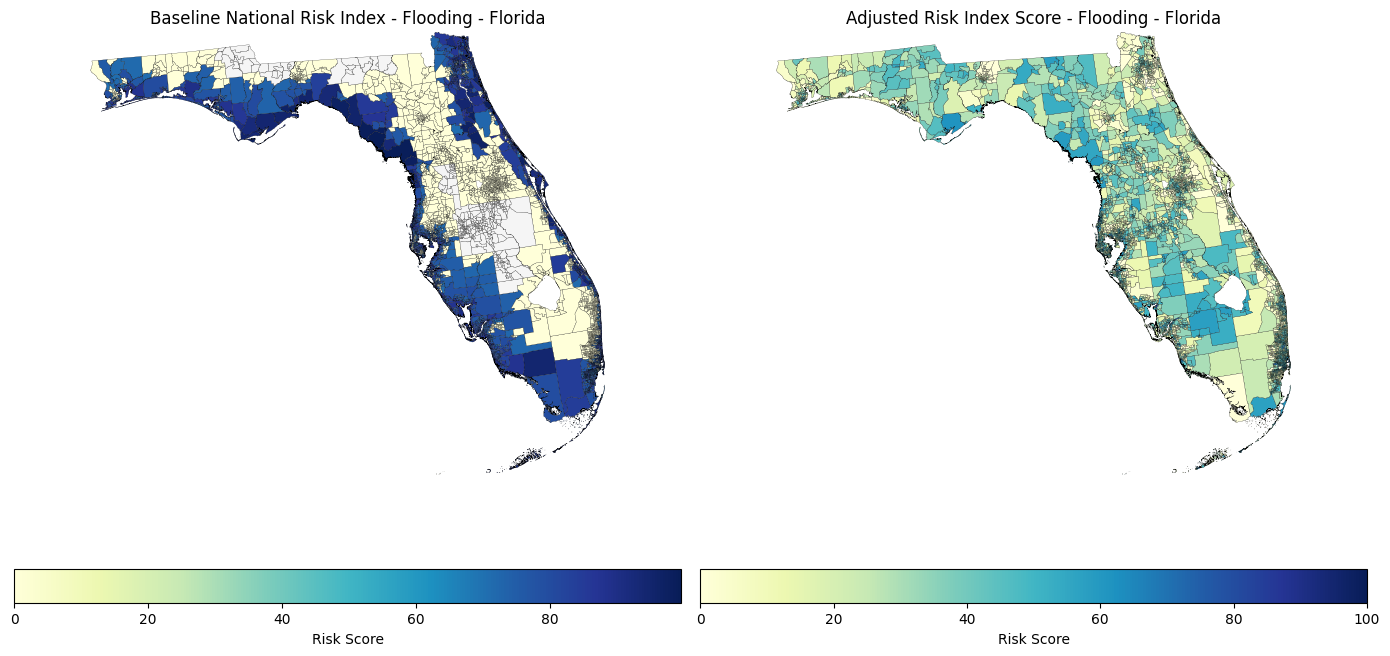

In [6]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Selected state
state_name = "Florida"

# Filters data to only include Florida
state_map = fl_tracts_clean[
    fl_tracts_clean["STATE"].str.lower() == state_name.lower()]

# Common color palette for both maps
map_colors = "YlGnBu"

# Plot original NRI flood risk
state_map.plot(
    column="CFLD_RISKS_x",
    ax=ax[0],
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    cmap=map_colors,
    legend_kwds={
        "label": "Risk Score",
        "orientation": "horizontal"},
    missing_kwds={
        "color": "whitesmoke",
        "label": "No Data" })

# Set map boundaries and styling
minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5

ax[0].set_xlim(minx - padding, maxx + padding)
ax[0].set_ylim(miny - padding, maxy + padding)
ax[0].set_title("Baseline National Risk Index - Flooding - Florida", fontsize=12)
ax[0].set_axis_off()

# Plot custom flood risk
state_map.plot(
    column="new_CFLD_RISKS",
    ax=ax[1],
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    cmap=map_colors,
    legend_kwds={
        "label": "Risk Score",
        "orientation": "horizontal"},
    missing_kwds={"color": "whitesmoke","label": "No Data"})

# Set map boundaries and styling
ax[1].set_xlim(minx - padding, maxx + padding)
ax[1].set_ylim(miny - padding, maxy + padding)
ax[1].set_title("Adjusted Risk Index Score - Flooding - Florida", fontsize=12)
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

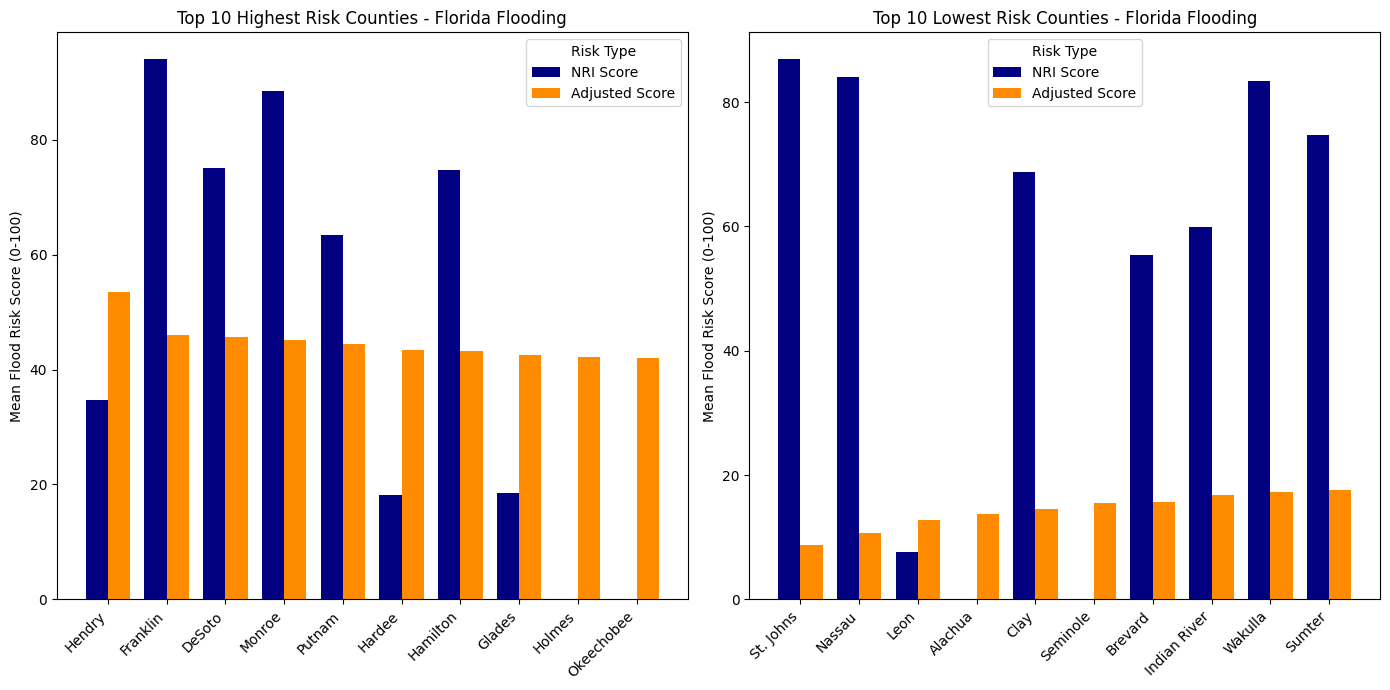

In [7]:
# Group county data using average original and adjusted flood risk scores
fl_counties_floods = fl_complete_data.groupby("COUNTY")[
    ["CFLD_RISKS", "new_CFLD_RISKS"]].mean()

# Select top 10 and bottom 10 counties for clearer comparison
fl_counties_floods_top = fl_counties_floods.nlargest(
    10, "new_CFLD_RISKS")

fl_counties_floods_bottom = fl_counties_floods.nsmallest(
    10, "new_CFLD_RISKS")

# Create plot space
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Common bar settings
width = 0.38
base_color = "navy"
compare_color = "darkorange"

# Top 10 counties
x = np.arange(len(fl_counties_floods_top))

axes[0].bar(
    x - width / 2,
    fl_counties_floods_top["CFLD_RISKS"],
    width,
    label="NRI Score",
    color=base_color)

axes[0].bar(
    x + width / 2,
    fl_counties_floods_top["new_CFLD_RISKS"],
    width,
    label="Adjusted Score",
    color=compare_color)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    fl_counties_floods_top.index,
    rotation=45,
    ha="right")

axes[0].set_ylabel("Mean Flood Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Florida Flooding")
axes[0].legend(title="Risk Type")


# Bottom 10 counties
x = np.arange(len(fl_counties_floods_bottom))

axes[1].bar(
    x - width / 2,
    fl_counties_floods_bottom["CFLD_RISKS"],
    width,
    label="NRI Score",
    color=base_color)

axes[1].bar(
    x + width / 2,
    fl_counties_floods_bottom["new_CFLD_RISKS"],
    width,
    label="Adjusted Score",
    color=compare_color)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    fl_counties_floods_bottom.index,
    rotation=45,
    ha="right")

axes[1].set_ylabel("Mean Flood Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Florida Flooding")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()

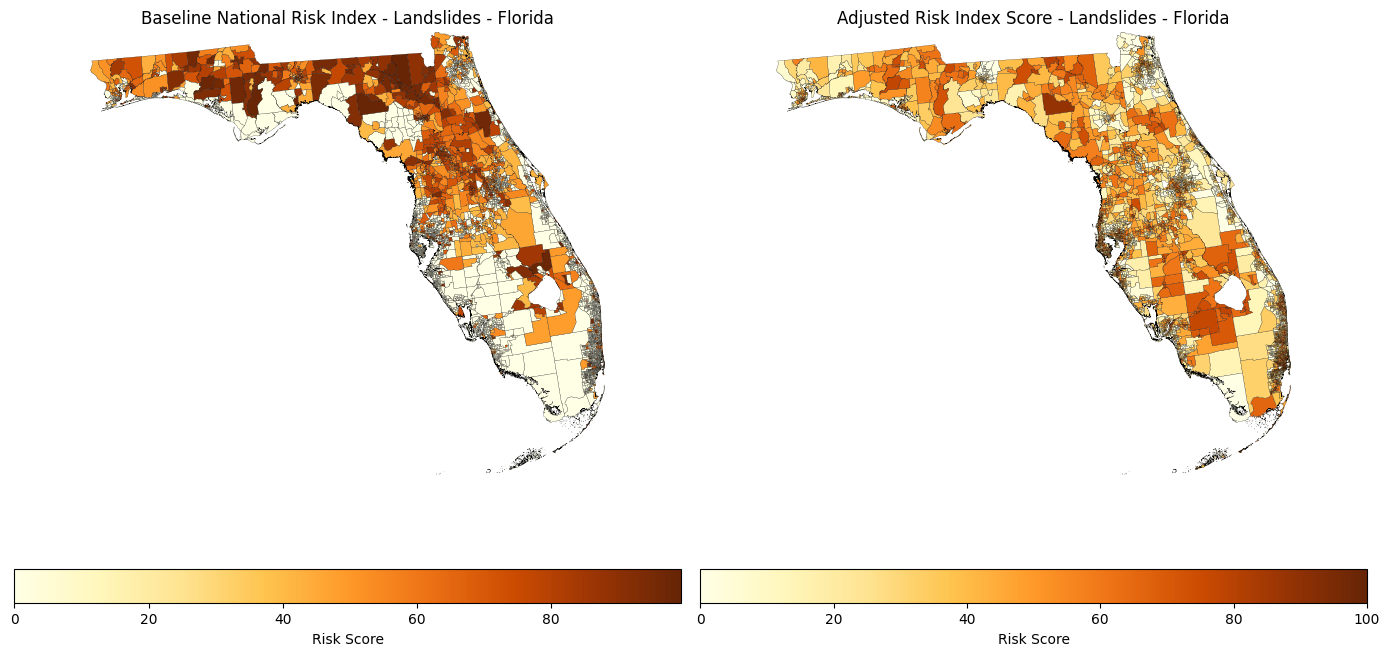

In [8]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Selected state
state_name = "Florida"

# Filters data to only include Florida
state_map = fl_tracts_clean[
    fl_tracts_clean["STATE"].str.lower() == state_name.lower()]

# Common color palette for both maps
map_colors = "YlOrBr"

# Plot original NRI landslide risk
state_map.plot(
    column="LNDS_RISKS_x",
    ax=ax[0],
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    cmap=map_colors,
    legend_kwds={
        "label": "Risk Score",
        "orientation": "horizontal"},
    missing_kwds={
        "color": "whitesmoke",
        "label": "No Data"})

# Set map boundaries and styling
minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5

ax[0].set_xlim(minx - padding, maxx + padding)
ax[0].set_ylim(miny - padding, maxy + padding)
ax[0].set_title("Baseline National Risk Index - Landslides - Florida", fontsize=12)
ax[0].set_axis_off()

# Plot custom landslide risk
state_map.plot(
    column="new_LNDS_RISKS",
    ax=ax[1],
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    cmap=map_colors,
    legend_kwds={
        "label": "Risk Score",
        "orientation": "horizontal"},
    missing_kwds={
        "color": "whitesmoke",
        "label": "No Data"})

# Set map boundaries and styling
ax[1].set_xlim(minx - padding, maxx + padding)
ax[1].set_ylim(miny - padding, maxy + padding)
ax[1].set_title("Adjusted Risk Index Score - Landslides - Florida", fontsize=12)
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

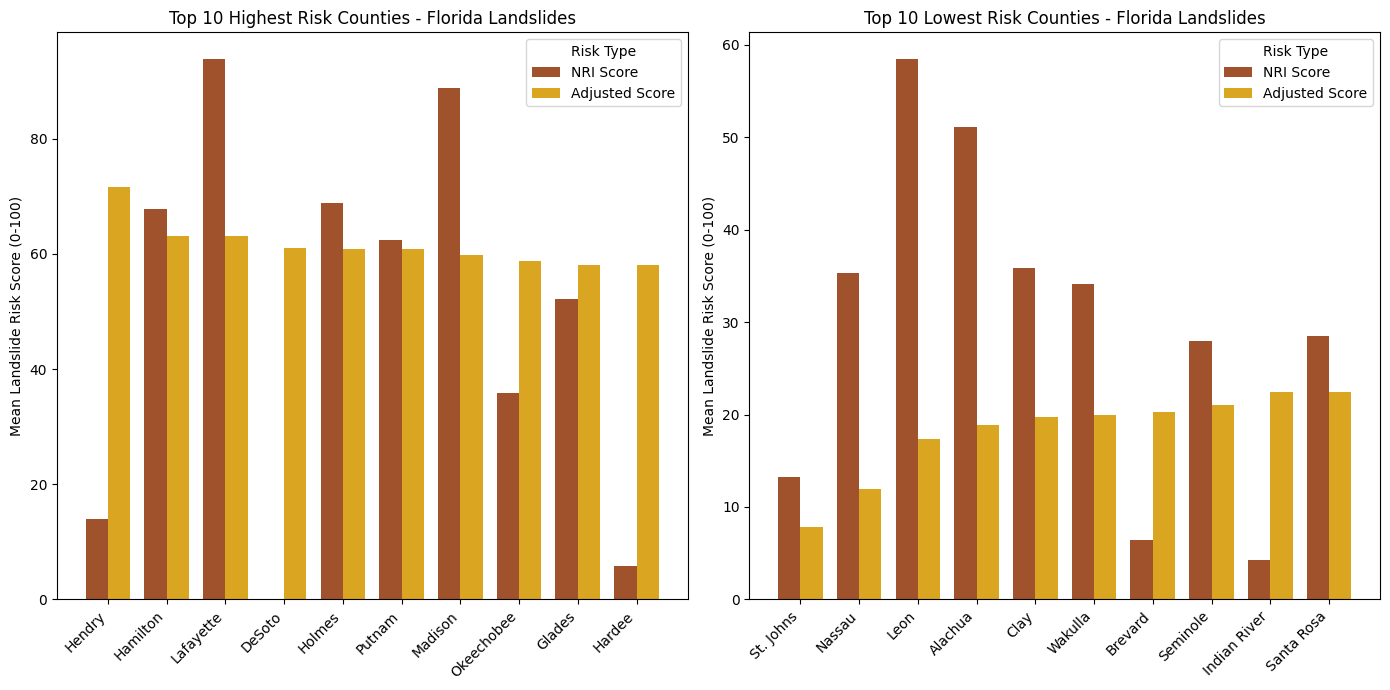

In [9]:
# Group county data using average original and adjusted landslide risk scores
fl_counties_landslides = fl_complete_data.groupby("COUNTY")[
    ["LNDS_RISKS", "new_LNDS_RISKS"]].mean()

# Select top 10 and bottom 10 counties for clearer comparison
fl_counties_landslides_top = fl_counties_landslides.nlargest(
    10, "new_LNDS_RISKS")

fl_counties_landslides_bottom = fl_counties_landslides.nsmallest(
    10, "new_LNDS_RISKS")

# Create plot space
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Common bar settings using map color theme
width = 0.38
base_color = "sienna"
compare_color = "goldenrod"

# Top 10 counties
x = np.arange(len(fl_counties_landslides_top))

axes[0].bar(
    x - width / 2,
    fl_counties_landslides_top["LNDS_RISKS"],
    width,
    label="NRI Score",
    color=base_color)

axes[0].bar(
    x + width / 2,
    fl_counties_landslides_top["new_LNDS_RISKS"],
    width,
    label="Adjusted Score",
    color=compare_color)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    fl_counties_landslides_top.index,
    rotation=45,
    ha="right")

axes[0].set_ylabel("Mean Landslide Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Florida Landslides")
axes[0].legend(title="Risk Type")

# Bottom 10 counties
x = np.arange(len(fl_counties_landslides_bottom))

axes[1].bar(
    x - width / 2,
    fl_counties_landslides_bottom["LNDS_RISKS"],
    width,
    label="NRI Score",
    color=base_color)

axes[1].bar(
    x + width / 2,
    fl_counties_landslides_bottom["new_LNDS_RISKS"],
    width,
    label="Adjusted Score",
    color=compare_color)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    fl_counties_landslides_bottom.index,
    rotation=45,
    ha="right")

axes[1].set_ylabel("Mean Landslide Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Florida Landslides")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()

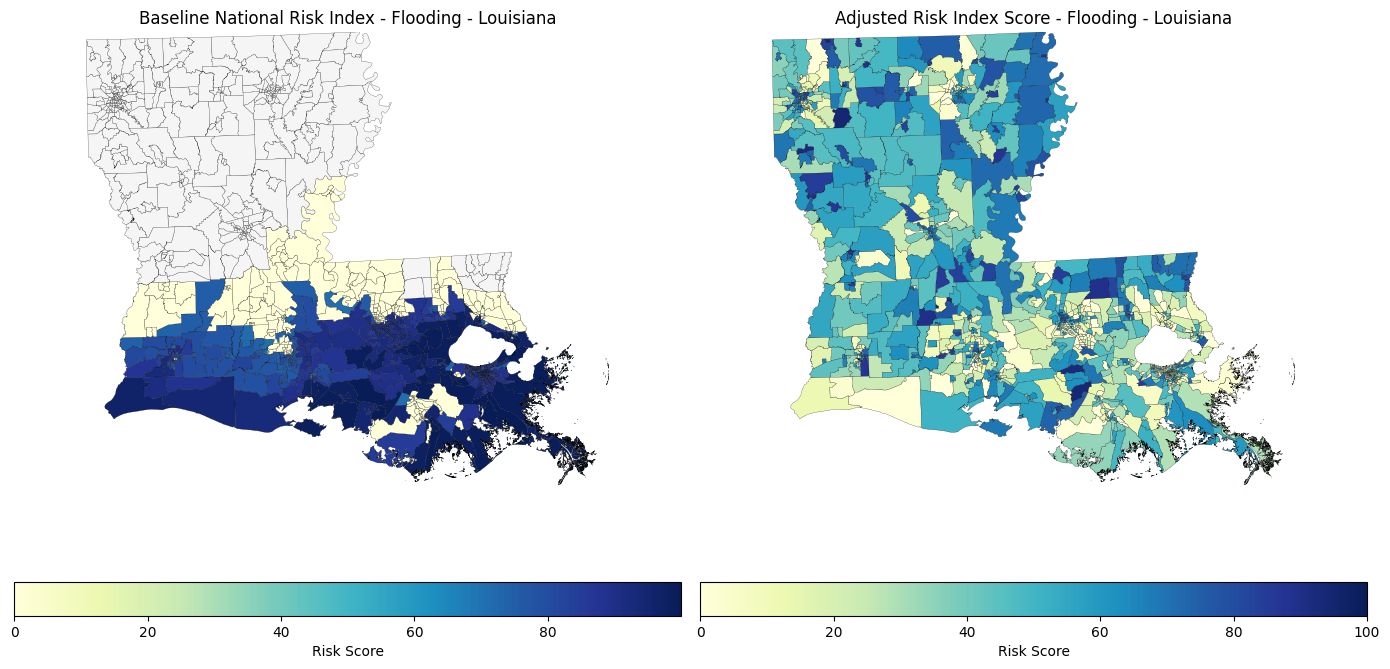

In [10]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Selected state
state_name = "Louisiana"

# Filters data to only include Louisiana
state_map = la_tracts_clean[
    la_tracts_clean["STATE"].str.lower() == state_name.lower()]


# Common color palette for both maps
map_colors = "YlGnBu"

# Plot original NRI flood risk
state_map.plot(
    column="CFLD_RISKS_x",
    ax=ax[0],
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    cmap=map_colors,
    legend_kwds={
        "label": "Risk Score",
        "orientation": "horizontal"},
    missing_kwds={
        "color": "whitesmoke",
        "label": "No Data"})

# Set map boundaries and styling
minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5

ax[0].set_xlim(minx - padding, maxx + padding)
ax[0].set_ylim(miny - padding, maxy + padding)
ax[0].set_title("Baseline National Risk Index - Flooding - Louisiana", fontsize=12)
ax[0].set_axis_off()

# Plot custom flood risk
state_map.plot(
    column="new_CFLD_RISKS",
    ax=ax[1],
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    cmap=map_colors,
    legend_kwds={
        "label": "Risk Score",
        "orientation": "horizontal"},
    missing_kwds={
        "color": "whitesmoke",
        "label": "No Data"})

# Set map boundaries and styling
ax[1].set_xlim(minx - padding, maxx + padding)
ax[1].set_ylim(miny - padding, maxy + padding)
ax[1].set_title("Adjusted Risk Index Score - Flooding - Louisiana", fontsize=12)
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

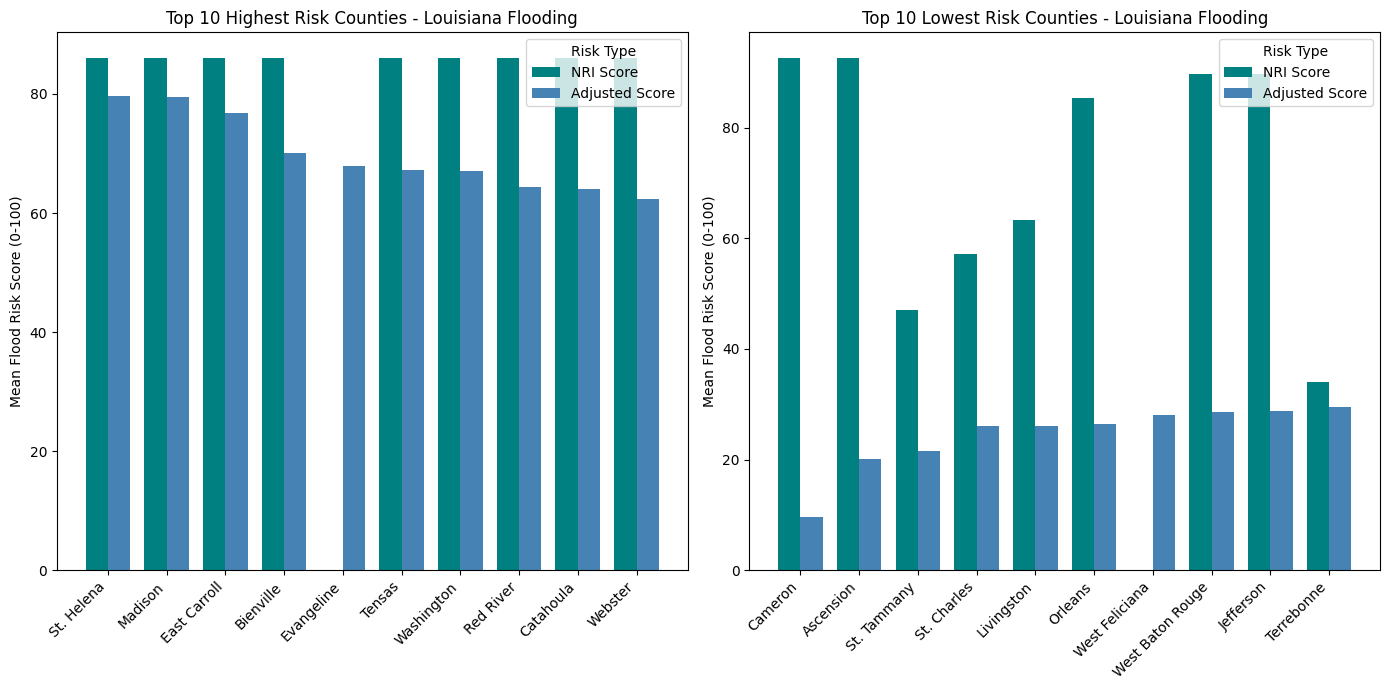

In [11]:
# Group county data using average original and adjusted flood risk scores
la_counties_floods = la_complete_data.groupby("COUNTY")[
    ["CFLD_RISKS", "new_CFLD_RISKS"]].mean()

# Select top 10 and bottom 10 counties for clearer comparison
la_counties_floods_top = la_counties_floods.nlargest(
    10, "new_CFLD_RISKS")

la_counties_floods_bottom = la_counties_floods.nsmallest(
    10, "new_CFLD_RISKS")

# Create plot space
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Common bar settings using flood map color theme
width = 0.38
base_color = "teal"
compare_color = "steelblue"

# Top 10 counties
x = np.arange(len(la_counties_floods_top))

axes[0].bar(
    x - width / 2,
    la_counties_floods_top["CFLD_RISKS"],
    width,
    label="NRI Score",
    color=base_color)

axes[0].bar(
    x + width / 2,
    la_counties_floods_top["new_CFLD_RISKS"],
    width,
    label="Adjusted Score",
    color=compare_color)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    la_counties_floods_top.index,
    rotation=45,
    ha="right")

axes[0].set_ylabel("Mean Flood Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Louisiana Flooding")
axes[0].legend(title="Risk Type")


# Bottom 10 counties
x = np.arange(len(la_counties_floods_bottom))

axes[1].bar(
    x - width / 2,
    la_counties_floods_bottom["CFLD_RISKS"],
    width,
    label="NRI Score",
    color=base_color)

axes[1].bar(
    x + width / 2,
    la_counties_floods_bottom["new_CFLD_RISKS"],
    width,
    label="Adjusted Score",
    color=compare_color)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    la_counties_floods_bottom.index,
    rotation=45,
    ha="right")

axes[1].set_ylabel("Mean Flood Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Louisiana Flooding")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()

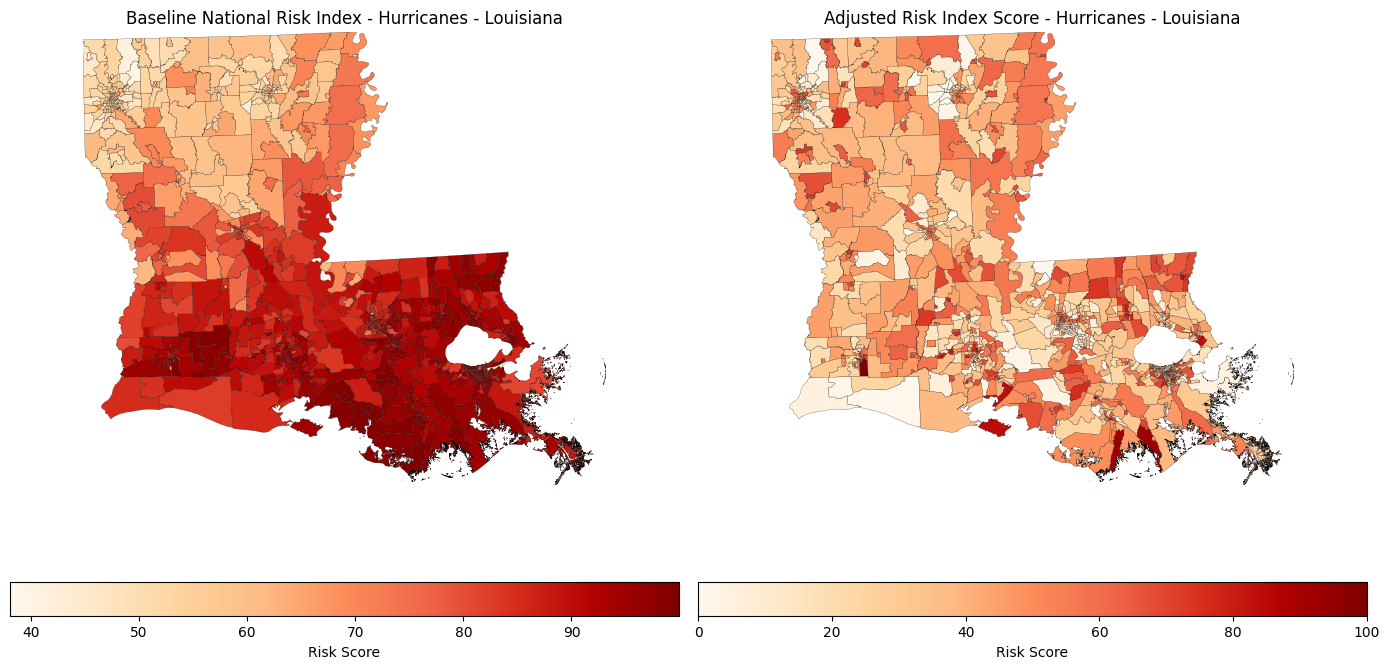

In [12]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Selected state
state_name = "Louisiana"

# Filters data to only include Louisiana
state_map = la_tracts_clean[
    la_tracts_clean["STATE"].str.lower() == state_name.lower()]

# Common color palette for both maps
map_colors = "OrRd"

# Plot original NRI hurricane risk
state_map.plot(
    column="HRCN_RISKS_x",
    ax=ax[0],
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    cmap=map_colors,
    legend_kwds={
        "label": "Risk Score",
        "orientation": "horizontal"},
    missing_kwds={
        "color": "whitesmoke",
        "label": "No Data"})

# Set map boundaries and styling
minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5

ax[0].set_xlim(minx - padding, maxx + padding)
ax[0].set_ylim(miny - padding, maxy + padding)
ax[0].set_title("Baseline National Risk Index - Hurricanes - Louisiana", fontsize=12)
ax[0].set_axis_off()

# Plot custom hurricane risk
state_map.plot(
    column="new_HRCN_RISKS",
    ax=ax[1],
    legend=True,
    linewidth=0.15,
    edgecolor="black",
    cmap=map_colors,
    legend_kwds={
        "label": "Risk Score",
        "orientation": "horizontal"},
    missing_kwds={
        "color": "whitesmoke",
        "label": "No Data"})

# Set map boundaries and styling
ax[1].set_xlim(minx - padding, maxx + padding)
ax[1].set_ylim(miny - padding, maxy + padding)
ax[1].set_title("Adjusted Risk Index Score - Hurricanes - Louisiana", fontsize=12)
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

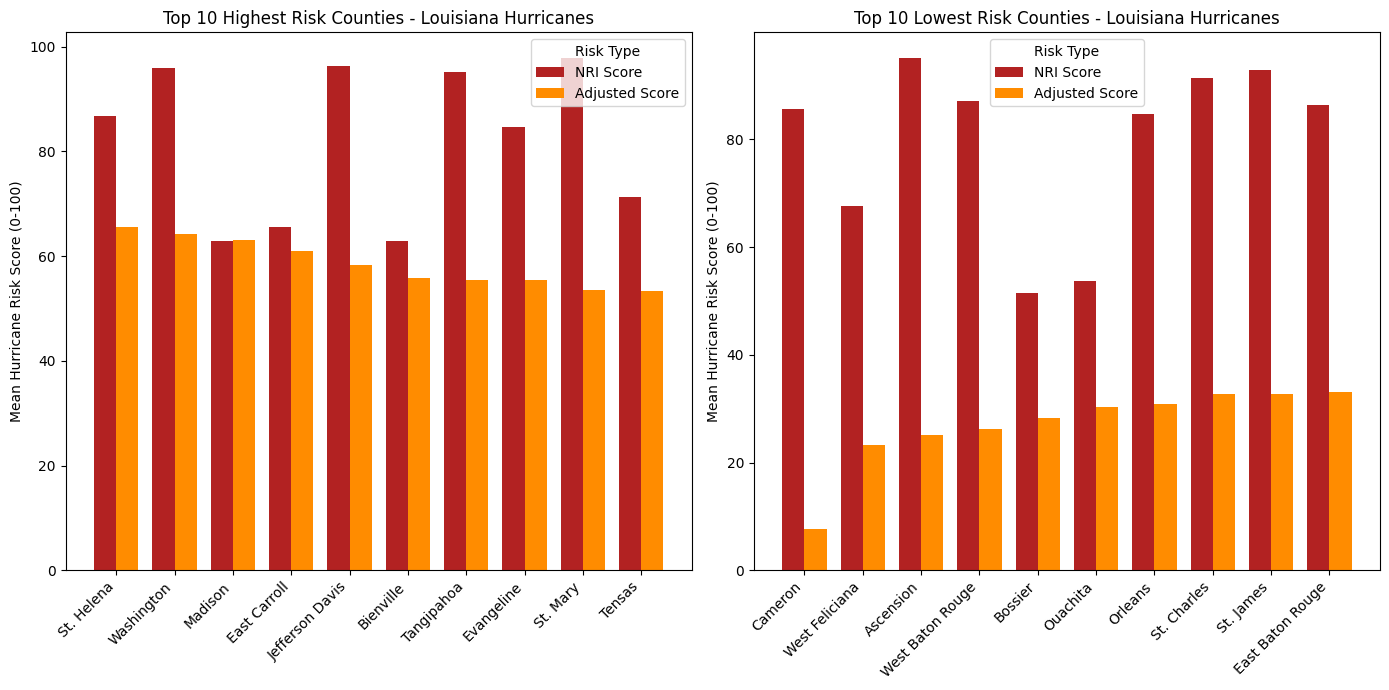

In [13]:
# Group county data using average original and adjusted hurricane risk scores
la_counties_hurricanes = la_complete_data.groupby("COUNTY")[
    ["HRCN_RISKS", "new_HRCN_RISKS"]].mean()

# Select top 10 and bottom 10 counties for clearer comparison
la_counties_hurricanes_top = la_counties_hurricanes.nlargest(
    10, "new_HRCN_RISKS")

la_counties_hurricanes_bottom = la_counties_hurricanes.nsmallest(
    10, "new_HRCN_RISKS")

# Create plot space
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Common bar settings using hurricane map color theme
width = 0.38
base_color = "firebrick"
compare_color = "darkorange"

# Top 10 counties
x = np.arange(len(la_counties_hurricanes_top))

axes[0].bar(
    x - width / 2,
    la_counties_hurricanes_top["HRCN_RISKS"],
    width,
    label="NRI Score",
    color=base_color)

axes[0].bar(
    x + width / 2,
    la_counties_hurricanes_top["new_HRCN_RISKS"],
    width,
    label="Adjusted Score",
    color=compare_color)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    la_counties_hurricanes_top.index,
    rotation=45,
    ha="right")

axes[0].set_ylabel("Mean Hurricane Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Louisiana Hurricanes")
axes[0].legend(title="Risk Type")


# Bottom 10 counties
x = np.arange(len(la_counties_hurricanes_bottom))

axes[1].bar(
    x - width / 2,
    la_counties_hurricanes_bottom["HRCN_RISKS"],
    width,
    label="NRI Score",
    color=base_color)

axes[1].bar(
    x + width / 2,
    la_counties_hurricanes_bottom["new_HRCN_RISKS"],
    width,
    label="Adjusted Score",
    color=compare_color)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    la_counties_hurricanes_bottom.index,
    rotation=45,
    ha="right")

axes[1].set_ylabel("Mean Hurricane Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Louisiana Hurricanes")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()